In [27]:

import numpy as np 
import pandas as pd 
import os


In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import cv2
import os
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical


from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model, Sequential, load_model
from tensorflow.keras.layers import Input


from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization, AveragePooling2D, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import DenseNet121

In [3]:
disease_types = ['Pepper__bell___Bacterial_spot','Pepper__bell___healthy','Potato___Early_blight','Potato___Late_blight','Potato___healthy','Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight','Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot','Tomato_Spider_mites_Two_spotted_spider_mite','Tomato__Target_Spot','Tomato__Tomato_YellowLeaf__Curl_Virus','Tomato__Tomato_mosaic_virus','Tomato_healthy']
data_dir = 'E:/Plant-Disease-Prediction-main(eg)/PlantVillage'
train_dir = os.path.join(data_dir)
#test_dir = os.path.join(data_dir, 'test')

In [4]:
train_data = []
for defects_id, sp in enumerate(disease_types):
    for file in os.listdir(os.path.join(train_dir, sp)):
        train_data.append(['{}/{}'.format(sp, file), defects_id, sp])
        
train = pd.DataFrame(train_data, columns=['File', 'DiseaseID','Disease Type'])
train.tail()

,File,DiseaseID,Disease Type
20634,Tomato_healthy/ff354b62-5981-43d1-8cfe-ac58bc2...,14,Tomato_healthy
20635,Tomato_healthy/ff774aec-2504-4d11-8a61-2fd74c6...,14,Tomato_healthy
20636,Tomato_healthy/ff8b36d5-feaf-4d2d-8126-18670a3...,14,Tomato_healthy
20637,Tomato_healthy/ffb39943-eabb-42cf-ad09-b17019e...,14,Tomato_healthy
20638,Tomato_healthy/ffd8aa68-138f-4114-96c7-21eef72...,14,Tomato_healthy


In [5]:
# Randomize the order of training set
SEED = 42
train = train.sample(frac=1, random_state=SEED) 
train.index = np.arange(len(train)) # Reset indices
train.head()

,File,DiseaseID,Disease Type
0,Tomato_healthy/9d197d8a-3f35-401a-8aa4-39f7e69...,14,Tomato_healthy
1,Potato___Early_blight/900514b4-8768-4370-bc53-...,2,Potato___Early_blight
2,Tomato_Septoria_leaf_spot/dc5f2f7d-8b86-402e-8...,9,Tomato_Septoria_leaf_spot
3,Tomato_healthy/e3b5600f-9c88-4060-826f-aa7c972...,14,Tomato_healthy
4,Tomato_Leaf_Mold/2e84cbfc-af2c-4c2b-9273-84275...,8,Tomato_Leaf_Mold


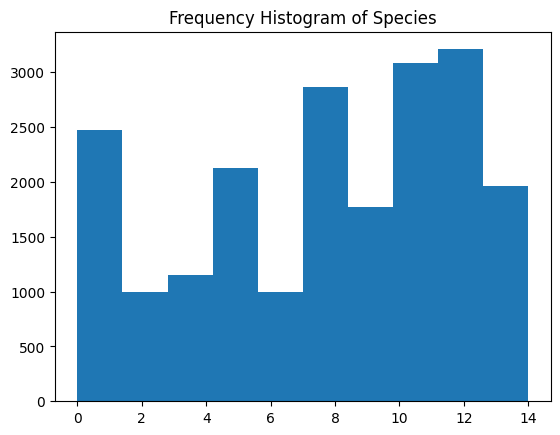

<Figure size 1200x1200 with 0 Axes>

In [6]:
# Plot a histogram
plt.hist(train['DiseaseID'])
plt.title('Frequency Histogram of Species')
plt.figure(figsize=(12, 12))
plt.show()

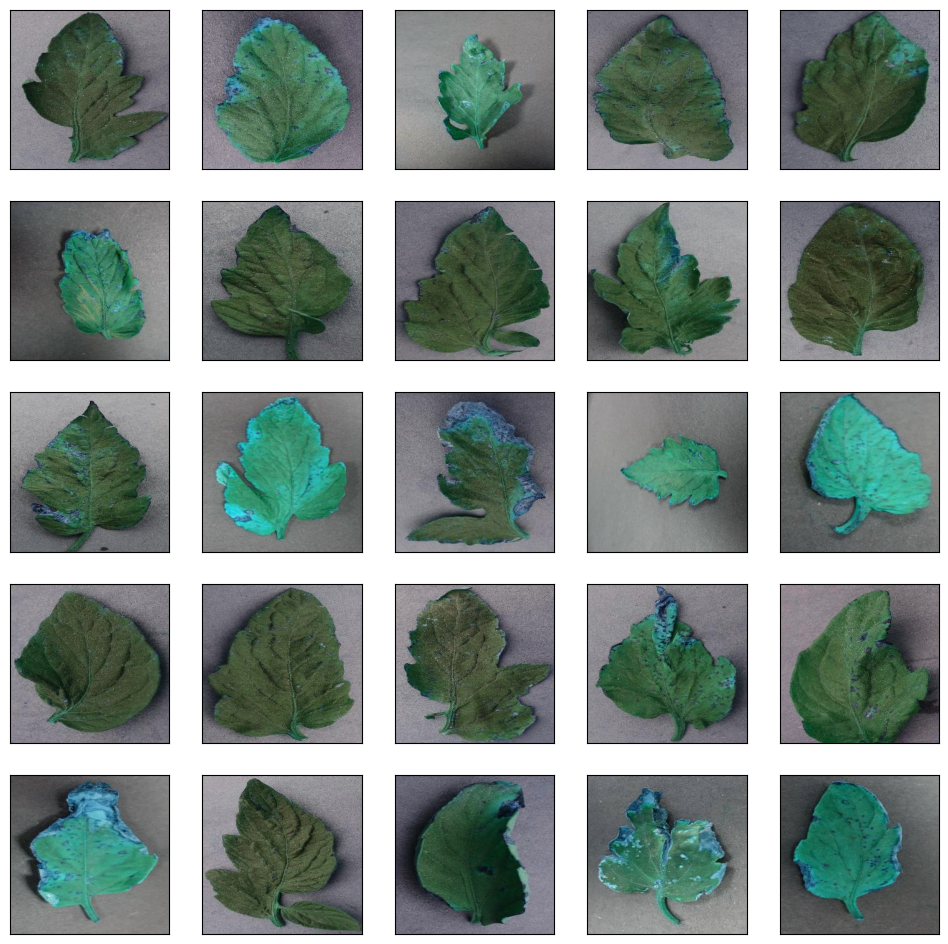

In [7]:
# Display images for different species
def plot_defects(defect_types, rows, cols):
    fig, ax = plt.subplots(rows, cols, figsize=(12, 12))
    defect_files = train['File'][train['Disease Type'] == defect_types].values
    n = 0
    for i in range(rows):
        for j in range(cols):
            image_path = os.path.join(data_dir, defect_files[n])
            ax[i, j].set_xticks([])
            ax[i, j].set_yticks([])
            ax[i, j].imshow(cv2.imread(image_path))
            n += 1
# Displays first n images of class from training set
plot_defects('Tomato_Bacterial_spot', 5, 5)

In [8]:
IMAGE_SIZE = 64

def read_image(filepath):
    return cv2.imread(os.path.join(data_dir, filepath)) # Loading a color image is the default flag
# Resize image to target size
def resize_image(image, image_size):
    return cv2.resize(image.copy(), image_size, interpolation=cv2.INTER_AREA)

In [9]:
X_train = np.zeros((train.shape[0], IMAGE_SIZE, IMAGE_SIZE, 3))
for i, file in tqdm(enumerate(train['File'].values)):
    image = read_image(file)
    if image is not None:
        X_train[i] = resize_image(image, (IMAGE_SIZE, IMAGE_SIZE))
# Normalize the data
X_Train = X_train / 255.
print('Train Shape: {}'.format(X_Train.shape))

0it [00:00, ?it/s]

20639it [05:27, 62.95it/s]


Train Shape: (20639, 64, 64, 3)


In [10]:
Y_train = train['DiseaseID'].values
Y_train = to_categorical(Y_train, num_classes=15)

In [11]:
BATCH_SIZE = 64

# Split the train and validation sets 
X_train, X_val, Y_train, Y_val = train_test_split(X_Train, Y_train, test_size=0.2, random_state=SEED)

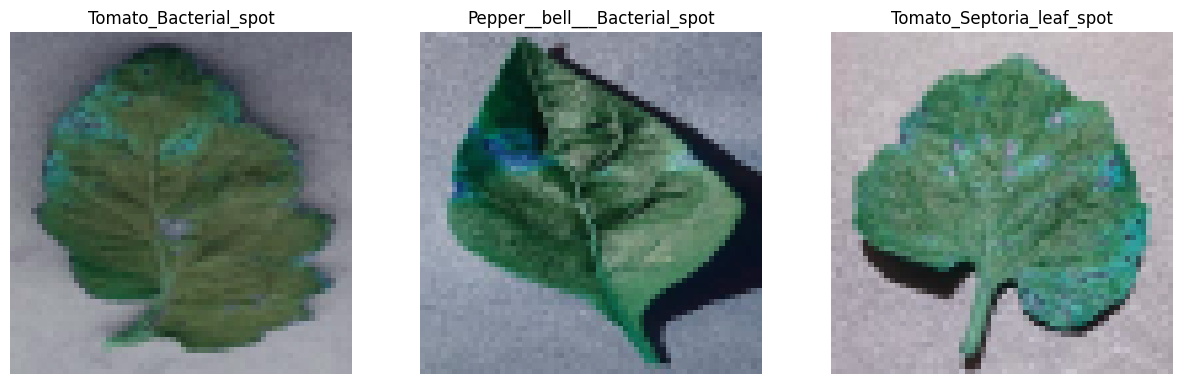

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(15, 15))
for i in range(3):
    ax[i].set_axis_off()
    ax[i].imshow(X_train[i])
    ax[i].set_title(disease_types[np.argmax(Y_train[i])])

In [13]:
EPOCHS = 50
SIZE=64
N_ch=3

In [17]:
from keras.applications import MobileNetV2
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14740\3307933897.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(64, 64, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [18]:
from keras.models import Model
from keras.layers import GlobalAveragePooling2D, Dense

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
predictions = Dense(15, activation='softmax')(x)
model = Model(inputs=base_model.input, outputs=predictions)


In [19]:
from keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

callbacks = [
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2),
    ModelCheckpoint('best_model.h5', save_best_only=True),
    early_stop
]


In [21]:
from keras.applications import MobileNetV2
from keras.models import Model
from keras.layers import GlobalAveragePooling2D, Dense, Dropout
from keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from keras.optimizers import Adam

# Build a lightweight MobileNetV2 model
def build_mobilenet(input_shape=(64, 64, 3), num_classes=15):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.2)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    
    # Freeze base model layers if needed for faster training
    for layer in base_model.layers:
        layer.trainable = False
    
    model.compile(optimizer=Adam(learning_rate=1e-3),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Build model
model = build_mobilenet()

# Define callbacks
callbacks = [
    ReduceLROnPlateau(monitor='val_accuracy', factor=0.5, patience=2),
    EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    ModelCheckpoint('best_model.h5', save_best_only=True)
]

# Train (optional: use small dataset for quick testing)
hist = model.fit(
    X_train[:2000], Y_train[:2000],  # Use full dataset or smaller subset
    batch_size=32,
    epochs=10,
    validation_data=(X_val[:500], Y_val[:500]),
    callbacks=callbacks,
    verbose=1
)


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_14740\4282825541.py:9: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=input_shape)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.2712 - loss: 2.5286

63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 200ms/step - accuracy: 0.2727 - loss: 2.5219 - val_accuracy: 0.5780 - val_loss: 1.3768 - learning_rate: 0.0010
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.5615 - loss: 1.4011

63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 160ms/step - accuracy: 0.5617 - loss: 1.4002 - val_accuracy: 0.6280 - val_loss: 1.1350 - learning_rate: 0.0010
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.6471 - loss: 1.1032

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.6472 - loss: 1.1027 - val_accuracy: 0.6720 - val_loss: 0.9976 - learning_rate: 0.0010
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step - accuracy: 0.7071 - loss: 0.9019

...

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 163ms/step - accuracy: 0.7387 - loss: 0.7833 - val_accuracy: 0.7040 - val_loss: 0.8966 - learning_rate: 0.0010
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step - accuracy: 0.7864 - loss: 0.6719

63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.7862 - loss: 0.6722 - val_accuracy: 0.6800 - val_loss: 0.8880 - learning_rate: 0.0010
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - accuracy: 0.8012 - loss: 0.6016

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 160ms/step - accuracy: 0.8011 - loss: 0.6017 - val_accuracy: 0.6920 - val_loss: 0.8780 - learning_rate: 0.0010
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8208 - loss: 0.5259

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 150ms/step - accuracy: 0.8208 - loss: 0.5260 - val_accuracy: 0.7020 - val_loss: 0.8705 - learning_rate: 5.0000e-04
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step - accuracy: 0.8503 - loss: 0.4854

63/63 ━━━━━━━━━━━━━━━━━━━━ 10s 152ms/step - accuracy: 0.8501 - loss: 0.4857 - val_accuracy: 0.7080 - val_loss: 0.8525 - learning_rate: 5.0000e-04
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 9s 140ms/step - accuracy: 0.8429 - loss: 0.4523 - val_accuracy: 0.7060 - val_loss: 0.8684 - learning_rate: 5.0000e-04


In [22]:
#model = load_model('../output/kaggle/working/model.h5')

final_loss, final_accuracy = model.evaluate(X_val, Y_val)
print('Final Loss: {}, Final Accuracy: {}'.format(final_loss, final_accuracy))


129/129 ━━━━━━━━━━━━━━━━━━━━ 14s 112ms/step - accuracy: 0.7032 - loss: 0.9388
Final Loss: 0.9519802927970886, Final Accuracy: 0.7073643207550049


129/129 ━━━━━━━━━━━━━━━━━━━━ 17s 112ms/step


Text(0.5, 192.58159722222217, 'Predicted')

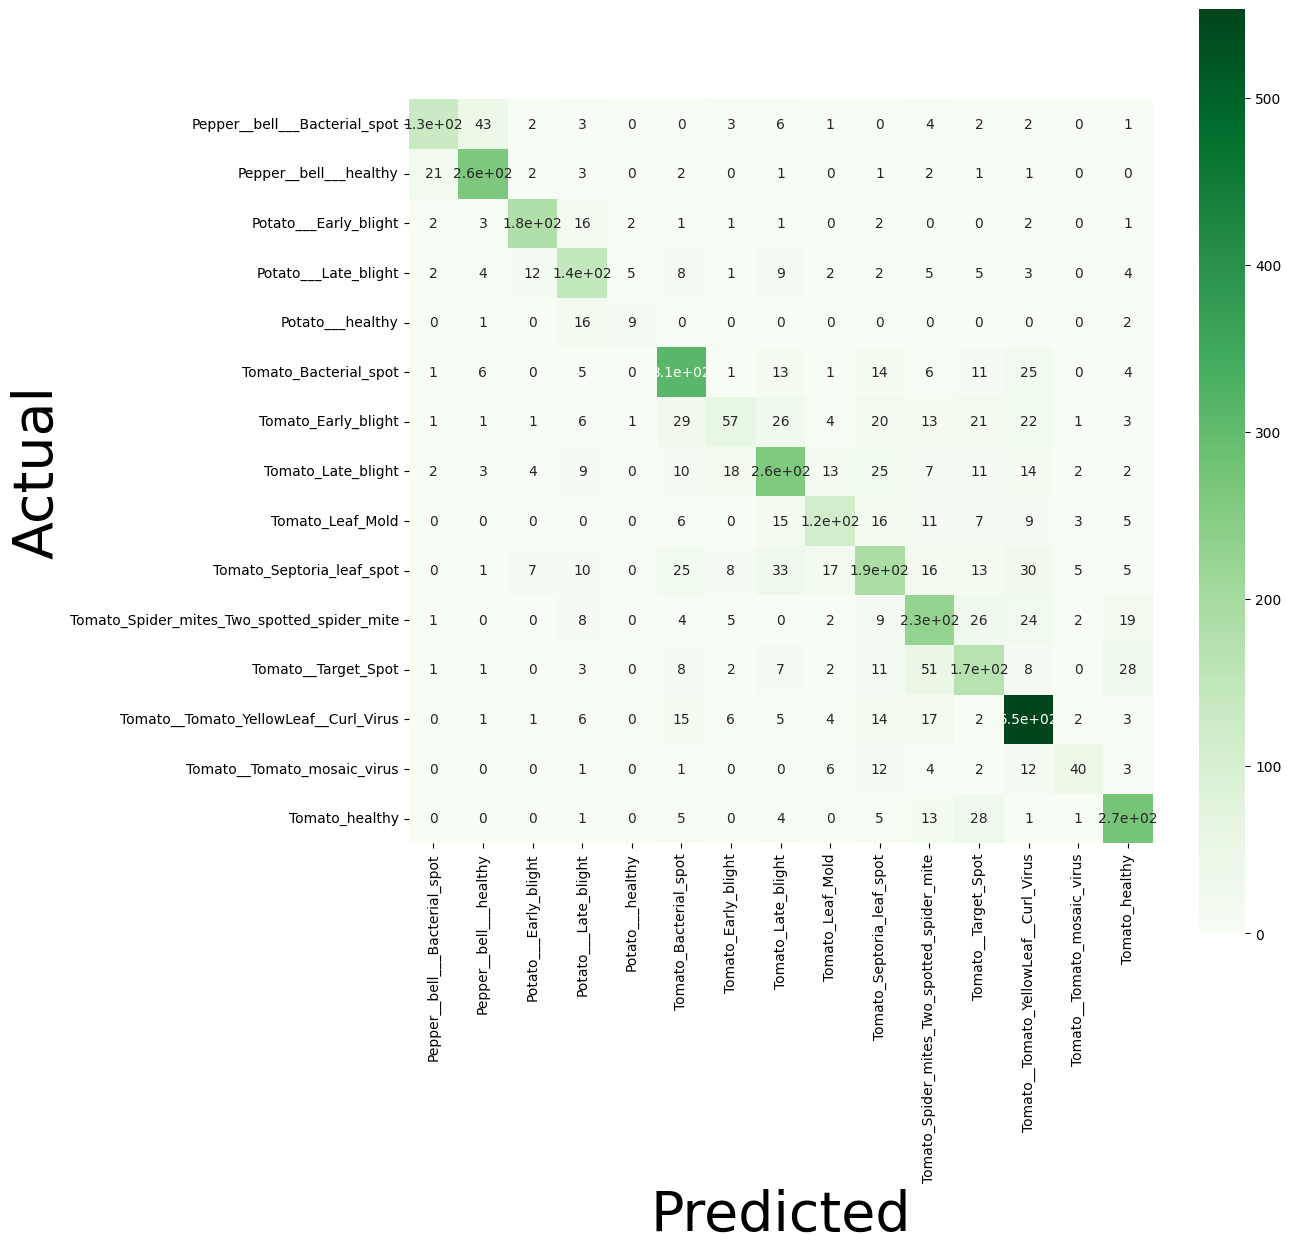

In [23]:
Y_pred = model.predict(X_val)

Y_pred = np.argmax(Y_pred, axis=1)
Y_true = np.argmax(Y_val, axis=1)

cm = confusion_matrix(Y_true, Y_pred)
plt.figure(figsize=(12, 12))
ax = sns.heatmap(cm, cmap=plt.cm.Greens, annot=True, square=True, xticklabels=disease_types, yticklabels=disease_types)
ax.set_ylabel('Actual', fontsize=40)
ax.set_xlabel('Predicted', fontsize=40)

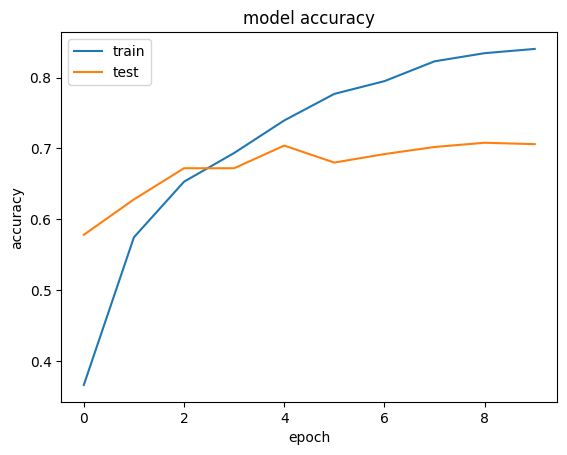

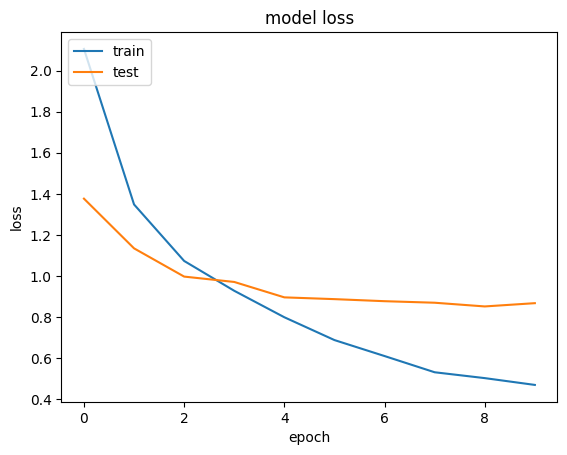

In [24]:
# accuracy plot 
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# loss plot
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

# Testing Disease Prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[2.1207903e-05 2.1035185e-06 9.1791073e-05 8.6233529e-05 2.1467995e-06
 1.9368804e-03 9.1786891e-01 7.3547393e-02 4.5640770e-04 5.1725786e-03
 1.7802975e-04 3.4659141e-04 4.3075273e-05 3.3779968e-05 2.1286127e-04]


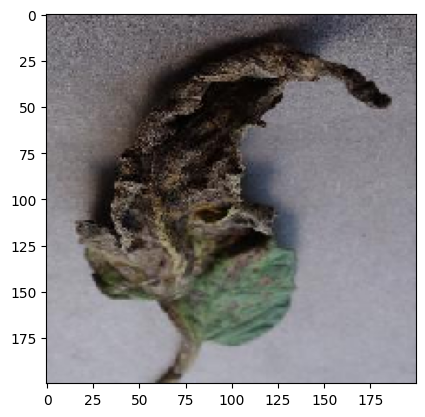

Prediction: Tomato_Early_blight


In [25]:
from skimage import io
from keras.preprocessing import image
#path='imbalanced/Scratch/Scratch_400.jpg'
img = image.load_img('E:/Plant-Disease-Prediction-main(eg)/PlantVillage/Tomato_Early_blight/4fd3f0e7-cdd9-4151-8734-5f0ad1f52614___RS_Erly.B 9564.JPG',target_size=(64, 64))
show_img=image.load_img('E:/Plant-Disease-Prediction-main(eg)/PlantVillage/Tomato_Early_blight/4fd3f0e7-cdd9-4151-8734-5f0ad1f52614___RS_Erly.B 9564.JPG',target_size=(200, 200))
disease_class = ['Pepper__bell___Bacterial_spot','Pepper__bell___healthy','Potato___Early_blight','Potato___Late_blight','Potato___healthy','Tomato_Bacterial_spot','Tomato_Early_blight','Tomato_Late_blight','Tomato_Leaf_Mold','Tomato_Septoria_leaf_spot','Tomato_Spider_mites_Two_spotted_spider_mite','Tomato__Target_Spot','Tomato__Tomato_YellowLeaf__Curl_Virus','Tomato__Tomato_mosaic_virus','Tomato_healthy']
x = image.img_to_array(img)
x = np.expand_dims(x, axis = 0)
#x = np.array(x, 'float32')
x /= 255

custom = model.predict(x)
print(custom[0])



#x = x.reshape([64, 64]);

#plt.gray()
plt.imshow(show_img)
plt.show()

a=custom[0]
ind=np.argmax(a)
        
print('Prediction:',disease_class[ind])

- - 